# ENGINEERING MATHEMATICS: DIFFERENTIAL EQUATIONS — 1007

## Chapter 3: Modeling with First-Order Equations

Modeling starts with a statement about rates.

1. Define the unknown quantity and its units.
2. Translate the rate statement into a differential equation.
3. Translate measurements into conditions.
4. Solve the equation and determine any unknown parameters.
5. Interpret the answer in the original units.

## 3.1 Linear Models

### Example 1: bacterial growth

A culture initially contains $P_0 > 0$ bacteria.  
After one hour it contains $3P_0/2$ bacteria.  
Assume that the growth rate is proportional to the population.

With $t$ measured in hours,
$$ A' = kA, \qquad A(0) = P_0, \qquad A(1) = \frac32 P_0. $$
Find the time at which $A(t) = 3P_0$.

Separation, or the linear-equation method, gives
$$ A(t) = Ce^{kt}. $$
The first measurement gives $C = P_0$; the second gives
$$ e^k = \frac32, \qquad k = \ln\frac32\ \mathrm{h}^{-1}. $$
Thus
$$ \boxed{A(t) = P_0e^{t\ln(3/2)}.} $$
The equilibrium $A = 0$ is excluded by the positive initial population.

The tripling time is
$$ \boxed{t = \frac{\ln3}{\ln(3/2)} \approx 2.71\ \mathrm{h}.} $$
Why were two measurements needed?  
There are two unknown constants: the initial scale $C$ and the model parameter $k$.  
For a known $k$, a single initial condition would determine the solution.

### Example 4: cooling a cake

A cake leaves an oven at $149^\circ\mathrm C$.  
After 3 minutes its temperature is $85^\circ\mathrm C$.  
The room stays at $21^\circ\mathrm C$.

Newton's law of cooling gives
$$ T' = k(T - 21), \qquad T(0) = 149, \qquad T(3) = 85. $$
Here $t$ is in minutes and cooling corresponds to $k < 0$.

Let $U = T - 21$. Then $U' = kU$ and $U(0) = 128$, so
$$ T(t) = 21 + 128e^{kt}. $$
Use the second measurement:
$$ 64 = 128e^{3k} \quad\Longrightarrow\quad k = -\frac{\ln2}{3}. $$
Therefore,
$$ \boxed{T(t) = 21 + 128\cdot 2^{-t/3}.} $$

To reach $22^\circ\mathrm C$,
$$ 1 = 128\cdot 2^{-t/3} = 2^{7 - t/3}, $$
so
$$ \boxed{t = 21\ \mathrm{minutes}} $$
after removal from the oven.

The linear method gives the same result using $T' - kT = -21k$  
and integrating factor $e^{-kt}$.

### Example 5: salt in a mixing tank

A well-mixed tank contains 1000 L of solution and initially 25 kg of salt.  
Brine containing 0.25 kg/L enters at 10 L/min.  
Mixture leaves at 10 L/min, so the volume stays constant.

Let $A(t)$ be the salt mass in kilograms.  
The outgoing concentration is $A(t)/1000$ kg/L.

The mass balance is
$$ \frac{dA}{dt} = \text{salt in per minute} - \text{salt out per minute}, $$
$$ A' = 10(0.25) - 10\frac{A}{1000} = 2.5 - 0.01A, \qquad A(0) = 25. $$
The equilibrium mass is $A_* = 250$ kg.

Shift by the equilibrium, or use the integrating factor $e^{0.01t}$:
$$ \boxed{A(t) = 250 - 225e^{-0.01t}\ \mathrm{kg}.} $$
The concentration is
$$ \boxed{c(t) = 0.25 - 0.225e^{-0.01t}\ \mathrm{kg/L}.} $$
It approaches the incoming concentration, $0.25$ kg/L.

### Series circuits: voltage balances

Let $i(t)$ be current, $q(t)$ charge, and $E(t)$ the source voltage.  
Then $i = dq/dt$.

| Component | Voltage drop |
|---|---|
| Resistor, resistance $R$ | $Ri$ |
| Inductor, inductance $L$ | $L\,di/dt$ |
| Capacitor, capacitance $C$ | $q/C$ |

Kirchhoff's voltage law equates their sum to the source voltage.

### LR series circuit

![Series circuit (source PDF, p. 88)](0923/de2-circuit-54.png)

An inductor and resistor in series satisfy
$$ \boxed{L\frac{di}{dt} + Ri = E(t).} $$
For constant $L > 0$, divide by $L$ and use integrating factor $e^{Rt/L}$.

For a constant source $E_0$ and $R > 0$,
$$ i(t) = \frac{E_0}{R} + \left(i(0) - \frac{E_0}{R}\right)e^{-Rt/L}. $$
The time constant is $\tau = L/R$.

#### Simulation: the current cannot jump

Switch a $12$ V source on and off every $0.1$ s across $R = 10\ \Omega$,  
and integrate
$$ L\frac{di}{dt} + Ri = E(t), \qquad i(0) = 0, $$
numerically for two inductances.  
A resistor by itself would copy the switch exactly.

In [5]:
import numpy as np
from scipy.integrate import odeint
lr_E0, lr_R = float(12), float(10)              # 12 V source, 10 ohm resistor
lr_period, lr_on = float(0.2), float(0.1)       # on for half of each period
def lr_source(t):
    return lr_E0 if t % lr_period < lr_on else 0.0
def lr_rhs(current, t, L):
    return (lr_source(t) - lr_R*float(current[0]))/L
lr_times = np.linspace(0, 0.6, 1201)
lr_curves = [(L, color, odeint(lr_rhs, [0.0], lr_times, args=(float(L),), hmax=0.001)[:, 0])
             for L, color in [(0.1, '#0072B2'), (0.5, '#D55E00')]]

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.


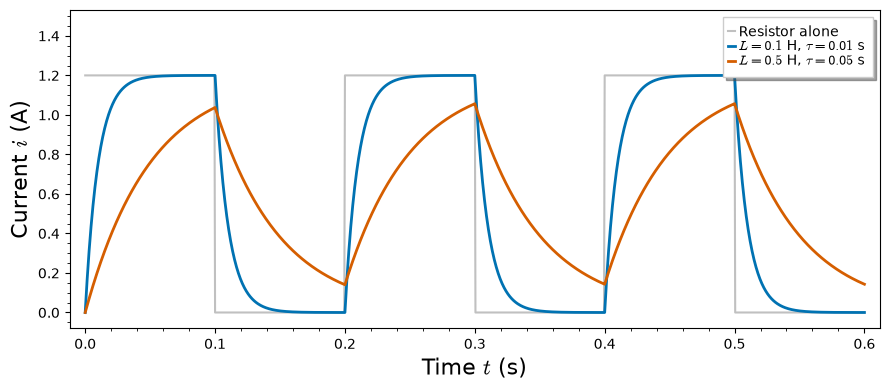

In [6]:
lr_plot = line([(t, lr_source(t)/lr_R) for t in lr_times], color='silver',
               thickness=1.5, legend_label='Resistor alone')
for L, color, current in lr_curves:
    lr_plot += line(list(zip(lr_times, current)), color=color, thickness=2,
                    legend_label=rf'$L = {float(L)}$ H, $\tau = {float(L)/lr_R}$ s')
lr_plot.show(xmin=0, xmax=0.6, ymin=-0.05, ymax=1.5, figsize=[9, 4],
             axes_labels=['Time $t$ (s)', 'Current $i$ (A)'],
             frame=True, axes=False, legend_options={'loc': 'upper right'})

**Read the picture:** the gray steps are $E(t)/R$, what a resistor alone would do.  
Both currents are continuous: at each switching the slope starts at $E_0/L$, never a jump.  
The small inductance, $\tau = 0.01$ s, nearly fills each $0.1$ s window;  
the large one, $\tau = 0.05$ s, only reaches $86\%$ of $1.2$ A and never fully empties.  
Larger $L$ means more inertia, so the current is smoother and lags further behind.

### RC series circuit

![Series circuit (source PDF, p. 89)](0923/de2-circuit-55.png)

A resistor and capacitor in series satisfy
$$ \frac qC + Ri = E(t), \qquad i = q', $$
so
$$ \boxed{R\frac{dq}{dt} + \frac qC = E(t).} $$
For positive constant $R, C$ and a constant source $E_0$,
$$ q(t) = CE_0 + [q(0) - CE_0]e^{-t/(RC)}. $$
The time constant is $\tau = RC$.

#### Simulation: the capacitor voltage cannot jump

Drive the same switched source through $R = 10\ \Omega$ into a capacitor,  
and integrate
$$ R\frac{dq}{dt} + \frac qC = E(t), \qquad q(0) = 0, $$
for two capacitances.  
The plot follows the capacitor voltage $q/C$ against the source.

In [7]:
def rc_rhs(charge, t, C):
    return (lr_source(t) - float(charge[0])/C)/lr_R
rc_curves = [(C, color, odeint(rc_rhs, [0.0], lr_times, args=(float(C),), hmax=0.001)[:, 0]/float(C))
             for C, color in [(0.001, '#0072B2'), (0.005, '#D55E00')]]

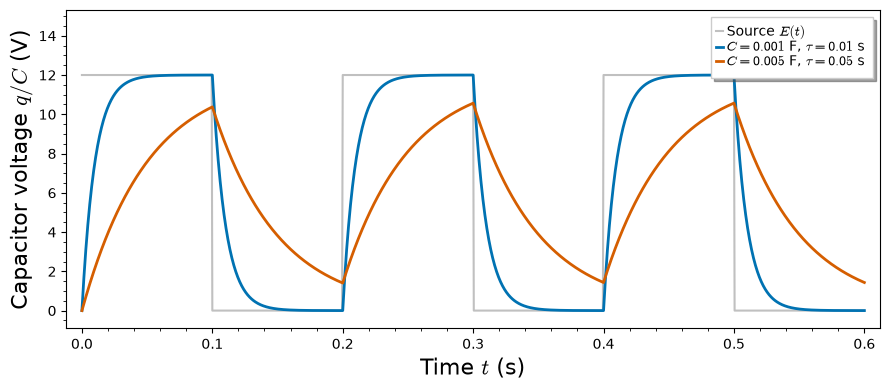

In [8]:
rc_plot = line([(t, lr_source(t)) for t in lr_times], color='silver',
               thickness=1.5, legend_label='Source $E(t)$')
for C, color, voltage in rc_curves:
    rc_plot += line(list(zip(lr_times, voltage)), color=color, thickness=2,
                    legend_label=rf'$C = {float(C)}$ F, $\tau = {float(C)*lr_R}$ s')
rc_plot.show(xmin=0, xmax=0.6, ymin=-0.6, ymax=15, figsize=[9, 4],
             axes_labels=['Time $t$ (s)', 'Capacitor voltage $q/C$ (V)'],
             frame=True, axes=False, legend_options={'loc': 'upper right'})

**Read the picture:** now the capacitor voltage is the continuous quantity,  
while the current $i = (E - q/C)/R$ jumps by $1.2$ A at every switching.  
The small capacitor, $\tau = 0.01$ s, charges fully inside each window;  
the large one, $\tau = 0.05$ s, reaches only $86\%$ of $12$ V.  
In the LR circuit the current was the smooth one and the inductor voltage jumped.

### LRC series circuit

![Series circuit (source PDF, p. 90)](0923/de2-circuit-56.png)

With all three components,
$$ \boxed{L\frac{d^2q}{dt^2} + R\frac{dq}{dt} + \frac qC = E(t).} $$
Since $i = q'$, the inductor introduces a second derivative of charge.  
This is a **second-order** linear equation, requiring two initial conditions  
when $L \ne 0$.

#### Simulation: three damping regimes

Close the switch once at $t = 0$ with a constant $12$ V source,  
$L = 1$ H and $C = 0.01$ F, so that
$$ L\frac{d^2q}{dt^2} + R\frac{dq}{dt} + \frac qC = E_0, \qquad q(0) = q'(0) = 0. $$
Critical damping occurs at $R = 2\sqrt{L/C} = 20\ \Omega$;  
the simulation compares $R = 5$, $20$, and $60\ \Omega$.

In [9]:
lrc_E0, lrc_L, lrc_C = float(12), float(1), float(0.01)
def lrc_rhs(state, t, R):
    charge, current = state
    return [current, (lrc_E0 - R*current - charge/lrc_C)/lrc_L]
lrc_times = np.linspace(0, 2, 2001)
lrc_curves = [(R, color, name, odeint(lrc_rhs, [0.0, 0.0], lrc_times, args=(float(R),))[:, 0])
              for R, color, name in [(5, '#0072B2', 'underdamped'), (20, '#009E73', 'critical'),
                                     (60, '#D55E00', 'overdamped')]]

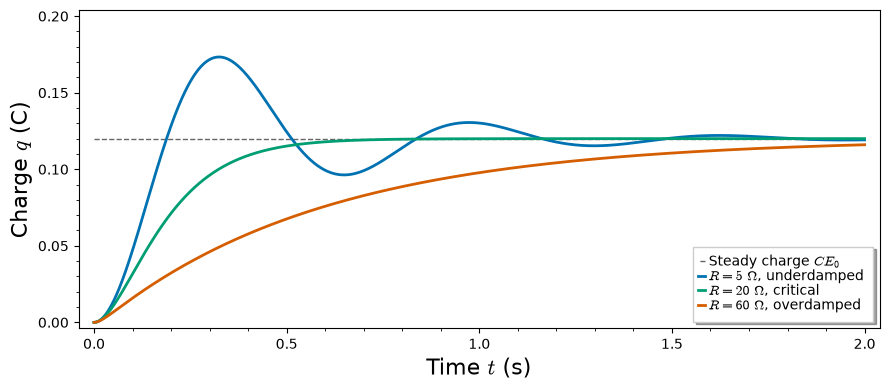

In [10]:
lrc_plot = line([(0, lrc_C*lrc_E0), (2, lrc_C*lrc_E0)], color='black',
                linestyle='--', alpha=0.6, legend_label='Steady charge $CE_0$')
for R, color, name, charge in lrc_curves:
    lrc_plot += line(list(zip(lrc_times, charge)), color=color, thickness=2,
                     legend_label=rf'$R = {R}\ \Omega$, {name}')
lrc_plot.show(xmin=0, xmax=2, ymin=0, ymax=0.2, figsize=[9, 4],
              axes_labels=['Time $t$ (s)', 'Charge $q$ (C)'],
              frame=True, axes=False, legend_options={'loc': 'lower right'})

**Read the picture:** all three settle at $CE_0 = 0.12$ C.  
Below critical resistance the charge overshoots to $0.173$ C and rings at about $10$ rad/s,  
which is $1/\sqrt{LC}$.  
At and above critical resistance the rise is monotone, and more resistance means slower.  
Oscillation needs the second derivative: the LR and RC circuits can only creep to their steady values.

### Example 7: switching on an LR circuit

Take $E = 12$ V, $L = 1/2$ H, $R = 10\ \Omega$, and $i(0) = 0$:
$$ \frac12 i' + 10i = 12 \quad\Longrightarrow\quad i' + 20i = 24. $$
Multiply by $e^{20t}$:
$$ (e^{20t}i)' = 24e^{20t}. $$
Integration gives $i = 6/5 + Ce^{-20t}$.

The initial current gives $C = -6/5$, hence
$$ \boxed{i(t) = \frac65(1 - e^{-20t})\ \mathrm A.} $$
The current approaches $1.2$ A and the time constant is $0.05$ s.

At switching, the inductor limits how fast current changes.  
At constant-source steady state, $i' = 0$ and the resistor sets $i = E/R$.

For an RC circuit under a constant source, charge approaches $CE_0$  
and current approaches zero.  
The resistor and capacitor together determine the charging timescale $RC$.

For either circuit, separate the decaying term from the long-term response.

## 3.2 Nonlinear Models

### The logistic equation

Exponential growth assumes a constant per-capita growth rate.  
To account for limited resources, let that rate decrease with population:
$$ \boxed{P' = P(a - bP) = aP\left(1 - \frac PK\right), \qquad K = \frac ab.} $$
Assume $a > 0$, $b > 0$.  
The number $K$ is the **carrying capacity**.

The equilibria are $P = 0$ and $P = K$.

- If $0 < P < K$, then $P' > 0$.
- If $P > K$, then $P' < 0$.
- Near $P = 0$, a small positive population grows away from zero.

Thus $K$ is stable and $0$ is unstable.  
For $P_0 > 0$, the solution approaches $K$ as $t \to \infty$.

![Logistic solution curves (source PDF, p. 94)](0923/de2-logistic-60.png)

### Solving the logistic equation

For a non-equilibrium solution, separate:
$$ \frac{dP}{P(a - bP)} = dt. $$
Use
$$ \frac{1}{P(a - bP)} = \frac{1/a}{P} + \frac{b/a}{a - bP}. $$
After integration,
$$ \frac1a\ln|P| - \frac1a\ln|a - bP| = t + C. $$

Exponentiating gives
$$ \frac{P}{a - bP} = C_1e^{at}. $$
With $P(0) = P_0$, the result can be written as
$$ \boxed{P(t) = \frac{aP_0}{bP_0 + (a - bP_0)e^{-at}}.} $$
For $P_0 > 0$, this is equivalently
$$ \boxed{P(t) = \frac{K}{1 + (K/P_0 - 1)e^{-at}}.} $$
The first form also includes $P_0 = 0$; both include $P_0 = K$ where defined.

Differentiate the rate to locate an inflection point:
$$ P'' = (a - 2bP)P'. $$
A growing solution with $0 < P < K$ changes concavity at $P = K/2$.  
If $P_0 > K/2$, that point lies before $t = 0$.

A solution beginning above $K$ decreases toward $K$.

### Example 1: spread of a virus on a campus

A closed campus contains 1000 students. Initially one is infected.  
Assume the spread rate is proportional to both the infected population  
and the population not yet infected, with no recovery during the modeled period.

Let $x(t)$ be the infected count, with $t$ in days:
$$ x' = kx(1000 - x), \qquad x(0) = 1, \qquad x(4) = 50. $$
Find $x(6)$.

Use the logistic formula with $K = 1000$:
$$ x(t) = \frac{1000}{1 + 999e^{-1000kt}}. $$
The observation after four days gives
$$ 50 = \frac{1000}{1 + 999e^{-4000k}}, $$
$$ e^{-4000k} = \frac{19}{999}, \qquad 1000k = \frac14\ln\frac{999}{19}. $$

Therefore,
$$ \boxed{x(t) = \frac{1000}{1 + 999e^{-rt}}, \qquad r = \frac14\ln\frac{999}{19} \approx 0.9906\ \mathrm{day}^{-1}.} $$
At six days,
$$ \boxed{x(6) \approx 276\text{ students}.} $$
The model treats population as continuous; round only when reporting a count.

In [11]:
import math
r = math.log(999 / 19) / 4
infected = lambda days: 1000 / (1 + 999 * math.exp(-r * days))
print(f'r = {r:.6f} per day')
print(f'x(0) = {infected(0):.0f}, x(4) = {infected(4):.0f}')
print(f'x(6) = {infected(6):.3f} students')

r = 0.990579 per day
x(0) = 1, x(4) = 50
x(6) = 276.222 students


### Variants of the logistic model

| Model | Interpretation |
|---|---|
| $P' = P(a - bP) + h$ | Constant immigration |
| $P' = P(a - bP) - h$ | Constant emigration or harvesting |
| $P' = P(a - bP) - cP$ | Emigration proportional to population |
| $P' = P(a - bP) + ce^{-kP}$ | Immigration decreases as population rises |

For each model, find equilibria from $P' = 0$ and inspect the sign of $P'$.

### The Gompertz equation

Another limited-growth model is
$$ P' = P(a - b\ln P) = bP\ln\frac KP, \qquad K = e^{a/b}, \qquad P > 0. $$
The per-capita growth rate is proportional to $\ln(K/P)$.

Set $u = \ln P$. Then
$$ u' = a - bu, $$
which is linear even though the original equation is nonlinear.

For $b > 0$ and $P(0) = P_0 > 0$,
$$ u(t) = \frac ab + \left(\ln P_0 - \frac ab\right)e^{-bt}, $$
so
$$ \boxed{P(t) = K\exp\left[\ln\left(\frac{P_0}{K}\right)e^{-bt}\right].} $$
The population approaches $K$.

### Chemical reaction rates

Consider a reaction $A + B \to C$.  
Let $x(t)$ be the amount of product formed, with $x(0) = 0$.

- Initially there are amounts $a$ of $A$ and $b$ of $B$.
- Making one unit of product consumes $s_1$ units of $A$ and $s_2$ units of $B$.
- The remaining reactant amounts are $a - s_1x$ and $b - s_2x$.
- Assume constant volume and a rate proportional to their product.

The model is
$$ \boxed{\frac{dx}{dt} = k(a - s_1x)(b - s_2x), \qquad k > 0.} $$
It is separable:
$$ \int \frac{dx}{(a - s_1x)(b - s_2x)} = kt + C. $$
The physically meaningful range is
$$ 0 \le x \le \min\left(\frac a{s_1}, \frac b{s_2}\right), $$
assuming positive initial amounts and positive consumption coefficients.

If $D = as_2 - bs_1 \ne 0$, partial fractions give
$$ \frac1D\ln\left|\frac{a - s_1x}{b - s_2x}\right| = kt + C. $$
If $D = 0$, write $\alpha = a/s_1 = b/s_2$ instead:
$$ x' = ks_1s_2(\alpha - x)^2. $$
Each case can be integrated, and the limiting reactant determines  
the maximum amount of product.

## Homework Due Sunday

Each problem asks for one key step.  
Give only the requested expression or classification;  
do not finish the differential equation.

### Antiderivative shapes

These are recognition drills, not integration computations.  
For the first group in Part A,  
write one function whose derivative is a nonzero constant multiple of the displayed function.  
Ignore the additive constant and do not find the multiplier.  
Assume $a > 0$ and treat all parameters as constants.

A1. $x^p$, where $p \ne -1$.  
A2. $1/x$.  
A3. $e^{ax}$.  
A4. $\sin(ax)$.  
A5. $\cos(ax)$.

A6. $\tan x$.  
A7. $\cot x$.  
A8. $\sec x$.  
A9. $\csc x$.  
A10. $\sec(ax)^2$.  
A11. $\sec(ax)\tan(ax)$.  
A12. $\csc(ax)^2$.  
A13. $\csc(ax)\cot(ax)$.

A14. $1/\sqrt{a^2 - x^2}$.  
A15. $1/(a^2 + x^2)$.  
A16. $1/[x\sqrt{x^2 - a^2}]$.  
A17. $1/\sqrt{x^2 + a^2}$.  
A18. $1/\sqrt{x^2 - a^2}$.  
A19. $x\sin(x^2)$.

For the remaining problems in Part A,  
give the requested number of functions whose linear span contains  
an antiderivative of the displayed function. Do not find the coefficients.

A20. Three functions for $\sin(x)^5$.  
A21. Two functions for $e^{2x}\cos x$.  
A22. Two functions for $1/[u(u - 4)]$.  
A23. Two functions for $1/(a^2 - x^2)$.

### Choose the easiest method

For each equation, name the easiest method that applies directly.  
Choose from separable (S), linear (L), exact (E),  
homogeneous substitution (H), Bernoulli (B),  
and $Ax + By + C$ substitution (L).  
Do not solve.



B1. $y' = x(1 + y^2)$.  
B2. $y' - \dfrac2x y = x^3$, where $x > 0$.  
B3. $2xy\,dx + (x^2 - 1)\,dy = 0$.  
B4. $y' = 1 + \dfrac yx$.

B5. $xy' + y = x^2y^2$, where $x > 0$.  
B6. $y' = (-2x + y)^2 - 7$.  
B7. $P' = P(a - bP)$, where $a, b > 0$.

### Exact or not?

For Part C, write $M_y$, $N_x$, and exact or not exact.  
Simplify both derivatives before comparing them, and use any stated domain  
as part of the decision.

C1. $(y\cos x + 2x)\,dx + \sin x\,dy = 0$.  
C2. $(y\cos x + 2x)\,dx - \sin x\,dy = 0$.

C3. $(2x + y^2)\,dx + (x^2 + 2y)\,dy = 0$.  
C4. $y\,dx + 2x\,dy = 0$.  
C5. $(ye^{xy} + 2x)\,dx + (xe^{xy} + 2y)\,dy = 0$.  
C6. $(ye^{xy} + 2x)\,dx + [(x + 1)e^{xy} + 2y]\,dy = 0$.

C7. On $x > 0$ and $y > 0$,
$$ (y\ln x + y\ln y - y)\,dx + [x\ln(xy) - x]\,dy = 0. $$
C8. $2y\sin(x)\cos(x)\,dx - \dfrac12\cos(2x)\,dy = 0$.

C9. On $x \ne 1$,
$$ y\frac{x^2 - 1}{x - 1}\,dx + \left(\frac{x^2}{2} + x\right)\,dy = 0. $$
C10. On $D = \mathbb{R}^2 \setminus \{(0, 0)\}$, determine whether
$$ \omega = -\frac{y}{x^2 + y^2}\,dx + \frac{x}{x^2 + y^2}\,dy $$
is exact.

### Find the integrating factor only

For Part D, show the qualifying one-variable ratio and write an integrating factor $\mu$.  
If both one-variable tests work, give both factors; if neither works, say so.  
Do not solve the resulting exact equation.

D1. $xy\,dx + (2x^2 + 3y^2 - 20)\,dy = 0$.  
D2. $y\,dx + x(1 + x)\,dy = 0$.

D3. $y(2x + 1)\,dx + x^2\,dy = 0$.  
D4. $dx + x\,dy = 0$.  
D5. $2xy\,dx + dy = 0$.

D6. $dx + 2xy\,dy = 0$.  
D7. $y\,dx - x\,dy = 0$.  
D8. $(x + y^2)\,dx + (x^2 + y)\,dy = 0$.

## Homework Due Wednesday

Keep the pieces separate.  
Unless a problem says otherwise, do not find the complete solution.

### Linear equations in pieces

E1. For $y' + 3y = 6$, write the homogeneous solution $y_h$ only.  
E2. For $y' + 3y = 6$, write one particular solution $y_p$ only.  
E3. For $y' + \dfrac2x y = x^2$, where $x > 0$, write the integrating factor only.  
E4. For the equation in E3, rewrite the equation as a product derivative only.

E5. For the equation in E3, write the homogeneous solution $y_h$ only.  
E6. For the equation in E3, write one particular solution $y_p$ only.  
E7. For $y' + 2xy = 2x$, rewrite the equation as a product derivative only.  
E8. For $y' + 2xy = 2x$, write one particular solution $y_p$ only.

### Transform, then stop

Use the stated substitution and write the transformed differential equation.  
Do not solve it.

F1. $y' = 1 + y/x$; use $u = y/x$.  
F2. $y' + y/x = x^2y^2$; use $u = y^{-1}$.  
F3. $y' = (-2x + y)^2 - 7$; use $u = -2x + y$.

F4. $P' = P(a - bP)$; use $u = 1/P$.  
F5. $P' = P(a - b\ln P)$; use $u = \ln P$.

For the remaining problems in Part F, choose a substitution yourself  
and write the transformed differential equation. Do not solve it.

F6. $y' = \dfrac{x + y}{x - y}$.  
F7. $y' + \dfrac2x y = xy^3$, where $x > 0$.  
F8. $y' = (x + 2y)^2 + 1$.

F9. $P' = P(4 - 2\ln P)$, where $P > 0$.  
F10. $xy' = y\ln(xy)$, where $xy > 0$.

### Read the model without solving

G1. For $T' = k(T - T_m)$, write the equilibrium temperature and the sign of $k$ during cooling.  
G2. A well-mixed tank has constant volume $V$, flow rate $r$, incoming concentration $c_{\mathrm{in}}$,  
and salt mass $A(t)$. Write the salt rate in and the salt rate out only.

G3. For an LR circuit and an RC circuit, state the quantity that cannot jump  
and write the time constant of each circuit.  
G4. For $P' = P(a - bP)$, write both equilibria, the carrying capacity,  
and the population at which the growth rate is largest.  
G5. In $A + B \to C$, producing one unit of $C$ consumes $s_1$ units of $A$  
and $s_2$ units of $B$. Write the two remaining amounts and the physical range of $x$.

### Put the pieces together

Use the given form; no derivation is needed.

H1. A solution of $y' + 3y = 6$ has the form $y = 2 + Ce^{-3x}$.  
If $y(0) = 5$, find only $C$.  
H2. A salt model has solution $A(t) = 250 + Ce^{-0.01t}$.  
If $A(0) = 25$, find $C$ and $\lim_{t \to \infty} A(t)$.